# Analyse RCEMIP — Simulation `large300`
## Transport vertical de la quantité de mouvement par la turbulence convective




## 1. Librairies et constantes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import gc
import os

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

Rd      = 287.05
Rv      = 461.5
EPSILON = Rd / Rv  # ≈ 0.622

DIR_3D = '3D'
DIR_2D = '2D'

def path3d(var):
    return os.path.join(DIR_3D, f'MESONH_RCE_large300_3D_{var}.nc')

def path2d(var):
    return os.path.join(DIR_2D, f'MESONH_RCE_large300_2D_{var}.nc')

BLOC = 2

print('Prêt.')


Prêt.


## 2. Lecture des dimensions 

In [30]:
# On ouvre un seul fichier juste pour lire les métadonnées
_ds = xr.open_dataset(path3d('ua'))
_da = _ds['ua']

dim_t = _da.dims[0]
dim_z = _da.dims[1]
dim_y = _da.dims[2]
dim_x = _da.dims[3]
alt    = _da[dim_z].values.copy()   # vecteur altitude 
n_t    = _da.sizes[dim_t]
n_z    = _da.sizes[dim_z]
n_y    = _da.sizes[dim_y]
n_x    = _da.sizes[dim_x]
times  = _da[dim_t].values.copy()

_ds.close()
del _ds, _da
gc.collect()

# Dernier tiers = état stationnaire
t_stat   = int(2 * n_t / 3)
idx_stat = slice(t_stat, None)
n_stat   = n_t - t_stat

time_days = times.astype('float64') //4

print(time_days)

print(f'Grille : {n_t} t  x  {n_z} z  x  {n_y} y  x  {n_x} x')
print(f'Altitude : {alt[0]:.0f} — {alt[-1]:.0f} ')
print(f'État stationnaire : t={t_stat} → {n_t-1}  ({n_stat} pas)')


[ 0.  0.  0.  0.  1.  1.  1.  1.  2.  2.  2.  2.  3.  3.  3.  3.  4.  4.
  4.  4.  5.  5.  5.  5.  6.  6.  6.  6.  7.  7.  7.  7.  8.  8.  8.  8.
  9.  9.  9.  9. 10. 10. 10. 10. 11. 11. 11. 11. 12. 12. 12. 12. 13. 13.
 13. 13. 14. 14. 14. 14. 15. 15. 15. 15. 16. 16. 16. 16. 17. 17. 17. 17.
 18. 18. 18. 18. 19. 19. 19. 19. 20. 20. 20. 20. 21. 21. 21. 21. 22. 22.
 22. 22. 23. 23. 23. 23. 24. 24. 24. 24.]
Grille : 100 t  x  74 z  x  128 y  x  2000 x
Altitude : 0 — 73 
État stationnaire : t=66 → 99  (34 pas)


## 3. PRW et auto-agrégation (fichier 2D natif)


In [31]:
ds_prw  = xr.open_dataset(path2d('prw'))
prw_all = ds_prw['prw'].load()   # (time, y, x) — quelques centaines de Mo max
ds_prw.close()

prw_stat = prw_all.isel({dim_t: idx_stat})
prw_mean = prw_stat.mean(dim=dim_t)         # carte 2D moyenne
prw_flat = prw_mean.values.ravel()  #Met tout en ligne

# Variance spatiale à chaque pas de temps (signal d'agrégation)
prw_var = prw_all.var(dim=[dim_y, dim_x]).values

print(f'PRW chargée. Plage : {prw_flat.min():.1f} — {prw_flat.max():.1f} kg/m²')
print(f'Médiane : {np.median(prw_flat):.1f} kg/m²')


PRW chargée. Plage : 15.5 — 40.5 kg/m²
Médiane : 28.0 kg/m²


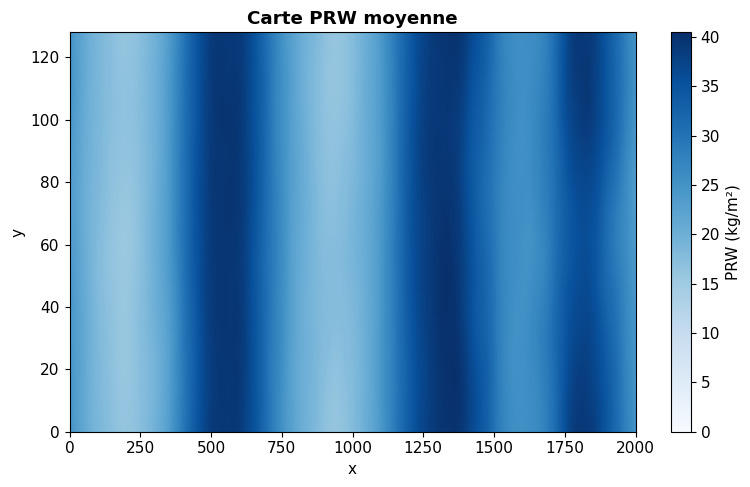

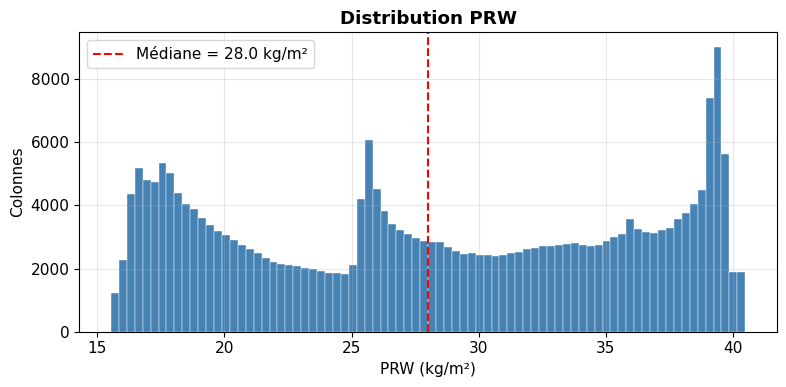

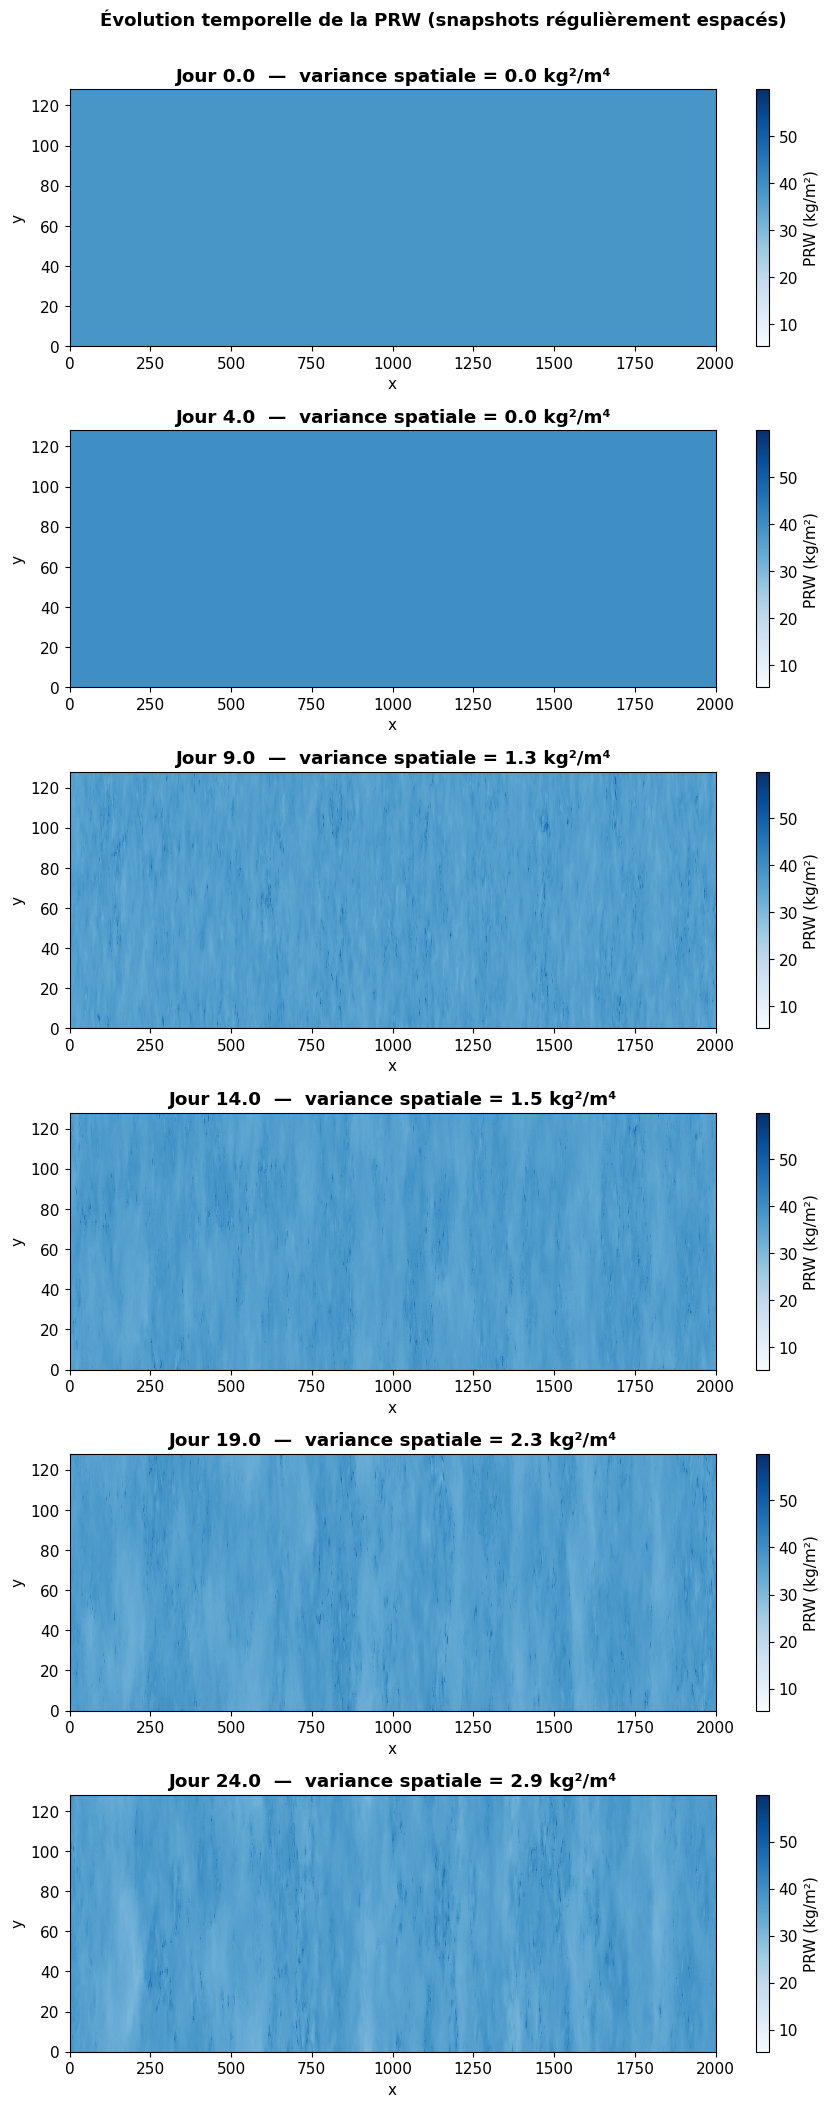

In [32]:
# ======================================================================
# PRW — visualisations empilées
# ======================================================================

# --- 1. Carte 2D PRW moyenne ---
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.pcolormesh(prw_mean.values, cmap='Blues', vmin=0)
fig.colorbar(im, ax=ax, label='PRW (kg/m²)')
ax.set_title('Carte PRW moyenne', fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
# Pas de set_aspect('equal') : x et y n'ont pas la même résolution/dimension
plt.tight_layout()
plt.show()

# --- 2. Distribution de la PRW ---
fig, ax = plt.subplots(figsize=(8, 4))
med = np.median(prw_flat)
ax.hist(prw_flat, bins=80, color='steelblue', edgecolor='white', lw=0.3)
ax.axvline(med, color='red', lw=1.5, linestyle='--', label=f'Médiane = {med:.1f} kg/m²')
ax.set_xlabel('PRW (kg/m²)')
ax.set_ylabel('Colonnes')
ax.set_title('Distribution PRW', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ======================================================================
# PRW — évolution temporelle par tranches
# Objectif : voir comment la structure spatiale de la PRW évolue
# On sélectionne N_TRANCHES instants régulièrement espacés sur toute la simulation
# ======================================================================
N_TRANCHES = 6  # nombre de snapshots à afficher

indices = np.linspace(0, n_t - 1, N_TRANCHES, dtype=int)

# Plage de couleur commune à tous les snapshots pour permettre la comparaison
vmin_prw = float(prw_all.min())
vmax_prw = float(prw_all.max())

fig, axes = plt.subplots(N_TRANCHES, 1, figsize=(9, 3.5 * N_TRANCHES))

for k, it in enumerate(indices):
    ax = axes[k]
    snap = prw_all.isel({dim_t: it}).values  # (ny, nx)
    jour = time_days[it]

    im = ax.pcolormesh(snap, cmap='Blues', vmin=vmin_prw, vmax=vmax_prw)
    fig.colorbar(im, ax=ax, label='PRW (kg/m²)')

    # Indicateur d'agrégation sur ce snapshot
    var_snap = snap.var()
    ax.set_title(f'Jour {jour:.1f}  —  variance spatiale = {var_snap:.1f} kg²/m⁴',
                 fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Évolution temporelle de la PRW (snapshots régulièrement espacés)',
             fontsize=13, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()

## 4. Seuil sec / humide

Seuil : 28.0 kg/m²
Humide : 50.0%   Sec : 50.0%


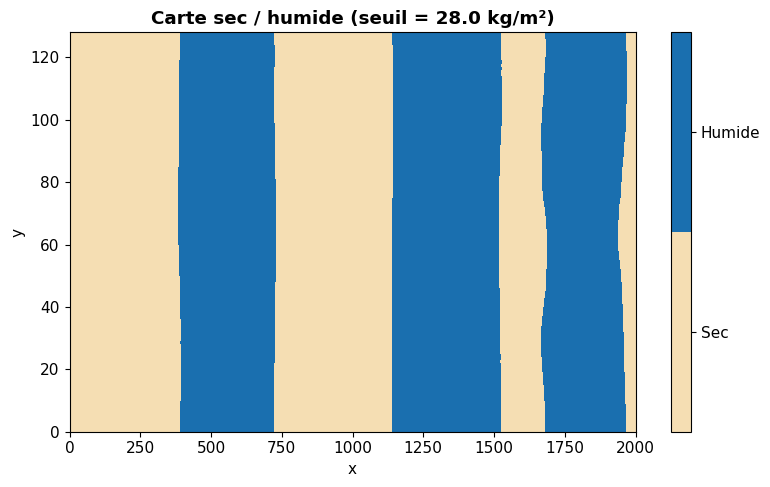

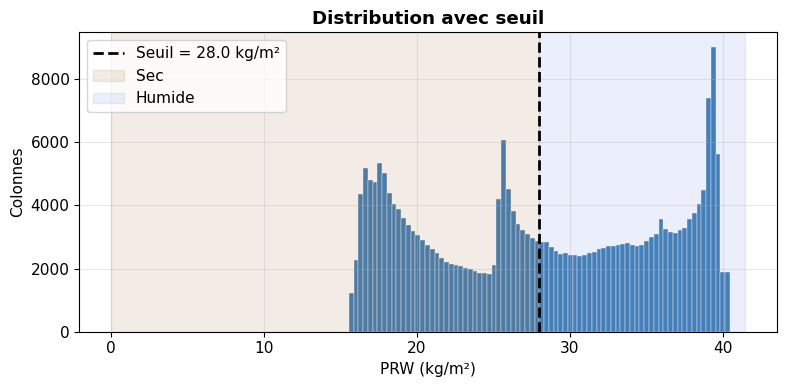

In [33]:
# Ajuster PRW_SEUIL selon le creux de la distribution observée au §3
PRW_SEUIL = float(np.median(prw_flat))
print(f'Seuil : {PRW_SEUIL:.1f} kg/m²')

mh = (prw_mean.values > PRW_SEUIL)   # bool (y, x)
ms = ~mh

print(f'Humide : {mh.mean()*100:.1f}%   Sec : {ms.mean()*100:.1f}%')

# --- Carte sec / humide ---
fig, ax = plt.subplots(figsize=(8, 5))
cmap_sh = mcolors.ListedColormap(['#f5deb3', '#1a6faf'])
im = ax.pcolormesh(mh.astype(int), cmap=cmap_sh, vmin=0, vmax=1)
cbar = fig.colorbar(im, ax=ax, ticks=[0.25, 0.75])
cbar.ax.set_yticklabels(['Sec', 'Humide'])
ax.set_title(f'Carte sec / humide (seuil = {PRW_SEUIL:.1f} kg/m²)', fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

# --- Distribution avec seuil ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prw_flat, bins=80, color='steelblue', edgecolor='white', lw=0.3)
ax.axvline(PRW_SEUIL, color='black', lw=2, linestyle='--',
           label=f'Seuil = {PRW_SEUIL:.1f} kg/m²')
ax.axvspan(0,                    PRW_SEUIL,        alpha=0.1, color='saddlebrown', label='Sec')
ax.axvspan(PRW_SEUIL, prw_flat.max() + 1,          alpha=0.1, color='royalblue',   label='Humide')
ax.set_xlabel('PRW (kg/m²)')
ax.set_ylabel('Colonnes')
ax.set_title('Distribution avec seuil', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Profil ρ₀

On charge `ta`, `pa`, `hus` **séquentiellement** (jamais simultanément)  
en accumulant les sommes nécessaires.


ρ₀ calculé sur 34 pas de temps.
  Surface : 1.183 kg/m³
  ~10 km  : 0.010 kg/m³


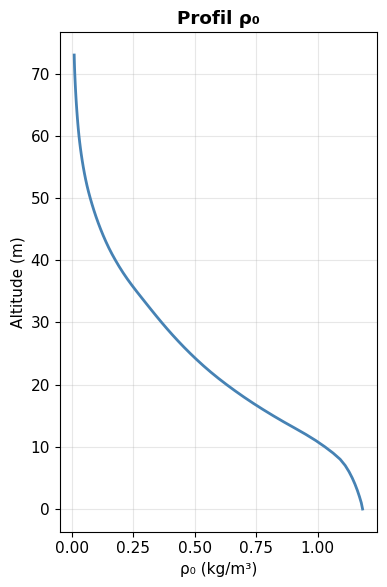

In [34]:
# Accumulation de p et T·(1 + qv/ε)/(1 + qv) = Tv

rho0_sum = np.zeros(n_z)
n_rho    = 0

ds_ta  = xr.open_dataset(path3d('ta')) #température
ds_pa  = xr.open_dataset(path3d('pa'))   #pression
ds_hus = xr.open_dataset(path3d('hus'))  #humidité spécifique

for t0 in range(t_stat, n_t, BLOC):#pour eviter de lire tout d un coup
    t1 = min(t0 + BLOC, n_t)
    sl = {dim_t: slice(t0, t1)}

    T_blk  = ds_ta['ta'].isel(sl).values   # (bloc, z, y, x)
    p_blk  = ds_pa['pa'].isel(sl).values
    qv_blk = ds_hus['hus'].isel(sl).values

    Tv_blk  = T_blk * (1.0 + qv_blk / EPSILON) / (1.0 + qv_blk)  #température virtuelle (formule non approchée)
    rho_blk = p_blk / (Rd * Tv_blk)  #formule des gaz parfait

    rho0_sum += rho_blk.mean(axis=(0, 2, 3)) * (t1 - t0)   #moyenne sur le temps et xy
    n_rho    += (t1 - t0)

    del T_blk, p_blk, qv_blk, Tv_blk, rho_blk
    gc.collect()

ds_ta.close() ; ds_pa.close() ; ds_hus.close()
del ds_ta, ds_pa, ds_hus
gc.collect()

rho0 = rho0_sum / n_rho   # profil 1D [kg/m³]

print(f'ρ₀ calculé sur {n_rho} pas de temps.')
print(f'  Surface : {rho0[0]:.3f} kg/m³')
print(f'  ~10 km  : {rho0[np.argmin(np.abs(alt-10000))]:.3f} kg/m³')

fig, ax = plt.subplots(figsize=(4, 6))
ax.plot(rho0, alt, color='steelblue', lw=2)
ax.set_xlabel('ρ₀ (kg/m³)') ; ax.set_ylabel('Altitude (m)')
ax.set_title('Profil ρ₀', fontweight='bold') ; ax.grid(True, alpha=0.3)
plt.tight_layout() ; plt.show()


## 6. Profil du vent horizontal moyen

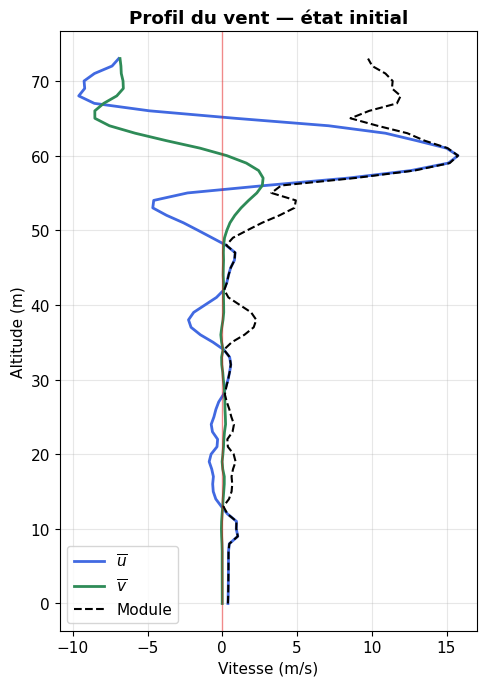

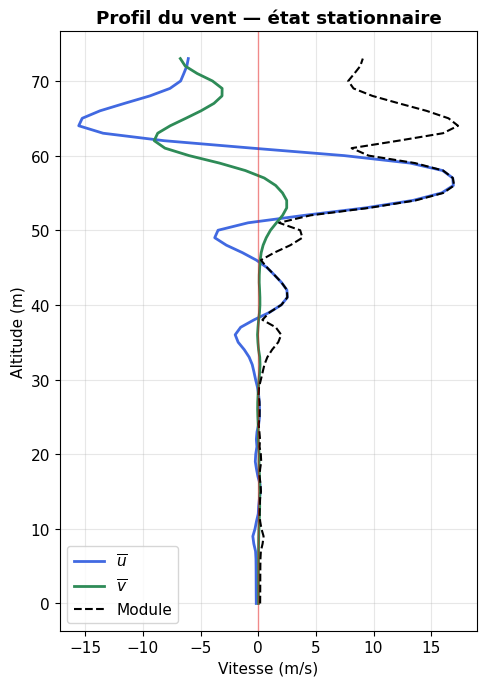

In [35]:
def calc_profil_vent(idx_slice):
    """Charge u et v séquentiellement, calcule le profil moyen."""
    ds_u = xr.open_dataset(path3d('ua'))
    u_m = ds_u['ua'].isel({dim_t: idx_slice}).mean(dim=[dim_t, dim_y, dim_x]).values
    ds_u.close()
    gc.collect()

    ds_v = xr.open_dataset(path3d('va'))
    v_m = ds_v['va'].isel({dim_t: idx_slice}).mean(dim=[dim_t, dim_y, dim_x]).values
    ds_v.close()
    gc.collect()

    return u_m, v_m

def plot_profil_vent(u_m, v_m, titre):
    fig, ax = plt.subplots(figsize=(5, 7))
    ax.plot(u_m,                       alt, color='royalblue', lw=2, label=r'$\overline{u}$')
    ax.plot(v_m,                       alt, color='seagreen',  lw=2, label=r'$\overline{v}$')
    ax.plot(np.sqrt(u_m**2 + v_m**2),  alt, 'k--', lw=1.5,         label='Module')
    ax.axvline(0, color='red', alpha=0.4, lw=1)
    ax.set_xlabel('Vitesse (m/s)') ; ax.set_ylabel('Altitude (m)')
    ax.set_title(titre, fontweight='bold') ; ax.grid(True, alpha=0.3) ; ax.legend()
    plt.tight_layout() ; plt.show()

u_init, v_init = calc_profil_vent(slice(0, 5))
plot_profil_vent(u_init, v_init, 'Profil du vent — état initial')

u_fin, v_fin = calc_profil_vent(idx_stat)
plot_profil_vent(u_fin, v_fin, 'Profil du vent — état stationnaire')


## 7. Bilan de QdM global

**Stratégie clé :** on ne charge jamais `u` et `w` ensemble.  
On calcule la covariance ⟨u′w′⟩ **niveau par niveau** :  
pour chaque niveau z, on extrait la tranche 2D (y, x) de u et de w,  
on calcule les anomalies, puis le produit. La tranche 2D est ~100× plus petite  
que le tableau 4D complet.

$$\text{Flux}(z) = \rho_0(z)\,\overline{u'w'}(z) = \rho_0(z) \cdot \frac{1}{N_t N_x N_y}\sum_{t,x,y} u'(t,z,x,y)\,w'(t,z,x,y)$$


In [36]:
# ======================================================================
# Calcul niveau par niveau pour minimiser la RAM
# Pour chaque niveau z :
#   - on lit la tranche u[:, z, :, :] et w[:, z, :, :] sur l'état stationnaire
#   - on calcule u' * w' et on moyenne sur (t, y, x)
# ======================================================================

flux_uw = np.zeros(n_z)   # ρ₀ <u'w'>  [kg m⁻¹ s⁻²]
flux_vw = np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua'))
ds_v = xr.open_dataset(path3d('va'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z):
    # Tranche (t_stat, y, x) pour ce niveau
    u_lev = ds_u['ua'].isel({dim_t: idx_stat, dim_z: iz}).values  # (n_stat, ny, nx)
    w_lev = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values

    # Anomalies spatiales (décomposition de Reynolds)
    u_p = u_lev - u_lev.mean(axis=(1, 2), keepdims=True)
    w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
    flux_uw[iz] = rho0[iz] * (u_p * w_p).mean()

    del u_lev, w_lev, u_p, w_p

    # v'w' au même niveau
    v_lev = ds_v['va'].isel({dim_t: idx_stat, dim_z: iz}).values
    w_lev = ds_w['wa'].isel({dim_t: idx_stat, dim_z: iz}).values
    v_p = v_lev - v_lev.mean(axis=(1, 2), keepdims=True)
    w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
    flux_vw[iz] = rho0[iz] * (v_p * w_p).mean()

    del v_lev, w_lev, v_p, w_p
    gc.collect()

    if iz % 10 == 0:
        print(f'  Niveau {iz}/{n_z-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_v.close() ; ds_w.close()
del ds_u, ds_v, ds_w
gc.collect()

print('Flux globaux calculés.')


  Niveau 0/73  (0 m)
  Niveau 10/73  (10 m)
  Niveau 20/73  (20 m)
  Niveau 30/73  (30 m)
  Niveau 40/73  (40 m)
  Niveau 50/73  (50 m)
  Niveau 60/73  (60 m)
  Niveau 70/73  (70 m)
Flux globaux calculés.


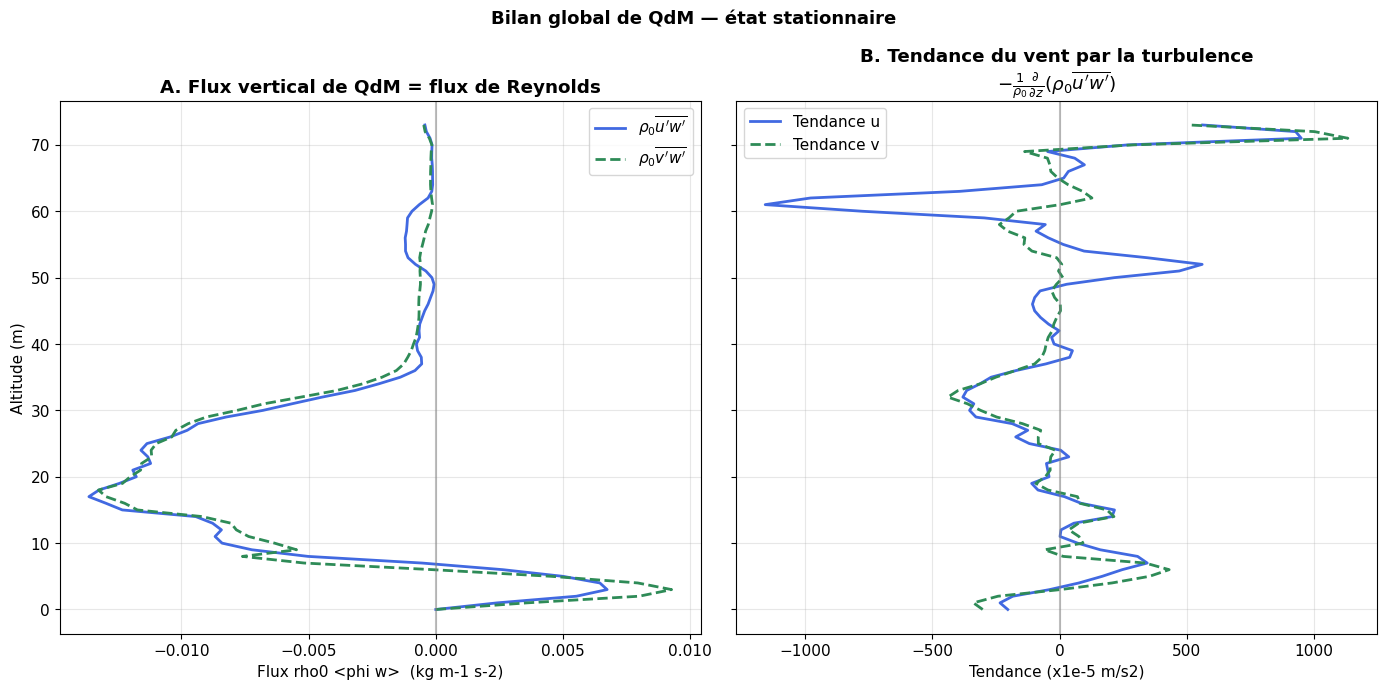

In [37]:
def tendance(flux_profil):
    """Force de Reynolds : -1/rho0 · d(rho0 <phi'w'>) / dz"""
    return -np.gradient(flux_profil, alt) / rho0

tend_u_glob = tendance(flux_uw)
tend_v_glob = tendance(flux_vw)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

ax1.plot(flux_uw, alt, color='royalblue', lw=2, label=r"$\rho_0\overline{u'w'}$")
ax1.plot(flux_vw, alt, color='seagreen',  lw=2, linestyle='--', label=r"$\rho_0\overline{v'w'}$")
ax1.axvline(0, color='grey', alpha=0.5)
ax1.set_xlabel('Flux rho0 <phi w>  (kg m-1 s-2)')
ax1.set_ylabel('Altitude (m)')
ax1.set_title('A. Flux vertical de QdM = flux de Reynolds', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

titre_b = (
    "B. Tendance du vent par la turbulence\n"
    r"$-\frac{1}{\rho_0}\frac{\partial}{\partial z}(\rho_0\overline{u'w'})$"
)
ax2.plot(tend_u_glob * 1e5, alt, color='royalblue', lw=2, label='Tendance u')
ax2.plot(tend_v_glob * 1e5, alt, color='seagreen',  lw=2, linestyle='--', label='Tendance v')
ax2.axvline(0, color='grey', alpha=0.5)
ax2.set_xlabel('Tendance (x1e-5 m/s2)')
ax2.set_title(titre_b, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Bilan global de QdM — état stationnaire', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Bilan conditionnel — décomposition par régime turbulent

Même stratégie niveau par niveau, mais on a besoin de `w`, `u`, `clw`, `cli`  
pour les masques. On les lit **séquentiellement** pour chaque niveau.

| Régime | Condition |
|--------|-----------|
| Convection nuageuse | w′ > +SEUIL_W et qc > SEUIL_QC |
| Thermiques secs | w′ > +SEUIL_W et qc ≤ SEUIL_QC |
| Subsidence = mouvement vertical descendant | w′ < −SEUIL_W |
| Petite turbulence | résidu |


In [38]:
SEUIL_W  = 0.05   # m/s
SEUIL_QC = 1e-5   # kg/kg

flux_conv = np.zeros(n_z)
flux_sec  = np.zeros(n_z)
flux_sub  = np.zeros(n_z)
flux_tot_cond = np.zeros(n_z)

ds_u   = xr.open_dataset(path3d('ua'))
ds_w   = xr.open_dataset(path3d('wa'))
ds_clw = xr.open_dataset(path3d('clw'))
ds_cli = xr.open_dataset(path3d('cli'))

for iz in range(n_z):
    sl = {dim_t: idx_stat, dim_z: iz}

    u_lev   = ds_u['ua'].isel(sl).values    # (n_stat, ny, nx)
    w_lev   = ds_w['wa'].isel(sl).values
    clw_lev = ds_clw['clw'].isel(sl).values
    cli_lev = ds_cli['cli'].isel(sl).values

    u_p = u_lev - u_lev.mean(axis=(1, 2), keepdims=True)
    w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
    qc  = clw_lev + cli_lev

    flux_loc = rho0[iz] * u_p * w_p   # (n_stat, ny, nx)

    m_conv = (w_p >  SEUIL_W) & (qc >  SEUIL_QC)
    m_sec  = (w_p >  SEUIL_W) & (qc <= SEUIL_QC)
    m_sub  = (w_p < -SEUIL_W)

    flux_conv[iz]     = np.where(m_conv, flux_loc, 0.0).mean()
    flux_sec[iz]      = np.where(m_sec,  flux_loc, 0.0).mean()
    flux_sub[iz]      = np.where(m_sub,  flux_loc, 0.0).mean()
    flux_tot_cond[iz] = flux_loc.mean()

    del u_lev, w_lev, clw_lev, cli_lev, u_p, w_p, qc, flux_loc
    del m_conv, m_sec, m_sub
    gc.collect()

    if iz % 10 == 0:
        print(f'  Niveau {iz}/{n_z-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_w.close() ; ds_clw.close() ; ds_cli.close()
del ds_u, ds_w, ds_clw, ds_cli
gc.collect()

flux_rest_cond = flux_tot_cond - (flux_conv + flux_sec + flux_sub)

print('Flux conditionnels calculés.')


  Niveau 0/73  (0 m)
  Niveau 10/73  (10 m)
  Niveau 20/73  (20 m)
  Niveau 30/73  (30 m)
  Niveau 40/73  (40 m)
  Niveau 50/73  (50 m)
  Niveau 60/73  (60 m)
  Niveau 70/73  (70 m)
Flux conditionnels calculés.


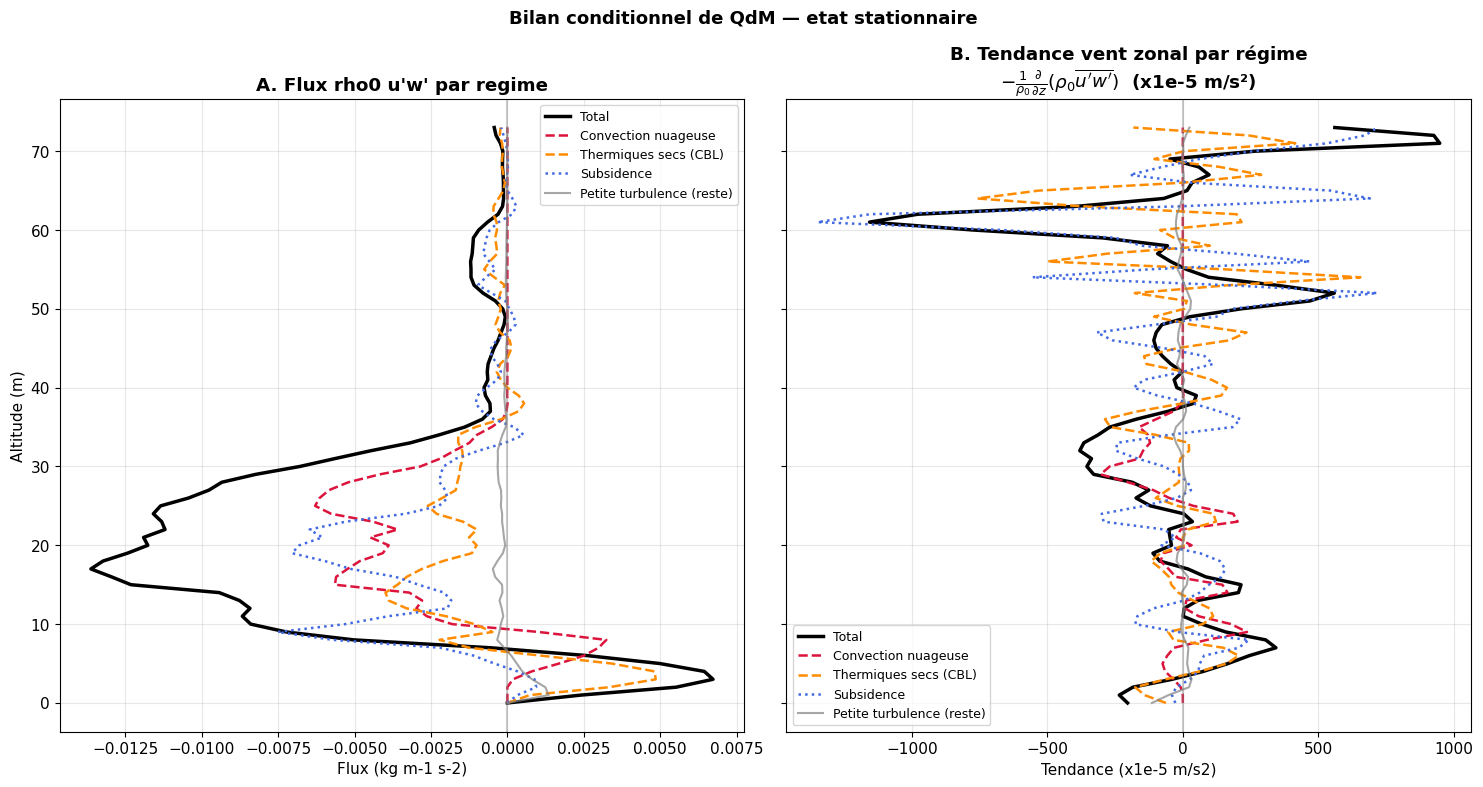

In [39]:
tend_conv = tendance(flux_conv)
tend_sec  = tendance(flux_sec)
tend_sub  = tendance(flux_sub)
tend_rest = tendance(flux_rest_cond)
tend_tot  = tendance(flux_tot_cond)

kw = dict(tot  = dict(color='black',      lw=2.5),
          conv = dict(color='crimson',    lw=1.8, linestyle='--'),
          sec  = dict(color='darkorange', lw=1.8, linestyle='--'),
          sub  = dict(color='royalblue',  lw=1.8, linestyle=':'),
          rest = dict(color='grey',       lw=1.5, alpha=0.7))

titre_b = (
    "B. Tendance vent zonal par régime\n"
    r"$-\frac{1}{\rho_0}\frac{\partial}{\partial z}(\rho_0\overline{u'w'})$"
    "  (x1e-5 m/s²)"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

ax1.plot(flux_tot_cond,  alt, label='Total',                    **kw['tot'])
ax1.plot(flux_conv,      alt, label='Convection nuageuse',       **kw['conv'])
ax1.plot(flux_sec,       alt, label='Thermiques secs (CBL)',     **kw['sec'])
ax1.plot(flux_sub,       alt, label='Subsidence',                **kw['sub'])
ax1.plot(flux_rest_cond, alt, label='Petite turbulence (reste)', **kw['rest'])
ax1.axvline(0, color='grey', alpha=0.4)
ax1.set_title('A. Flux rho0 u\'w\' par regime', fontweight='bold')
ax1.set_xlabel('Flux (kg m-1 s-2)')
ax1.set_ylabel('Altitude (m)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

sc = 1e5
ax2.plot(tend_tot  * sc, alt, label='Total',                    **kw['tot'])
ax2.plot(tend_conv * sc, alt, label='Convection nuageuse',       **kw['conv'])
ax2.plot(tend_sec  * sc, alt, label='Thermiques secs (CBL)',     **kw['sec'])
ax2.plot(tend_sub  * sc, alt, label='Subsidence',                **kw['sub'])
ax2.plot(tend_rest * sc, alt, label='Petite turbulence (reste)', **kw['rest'])
ax2.axvline(0, color='grey', alpha=0.4)
ax2.set_title(titre_b, fontweight='bold')
ax2.set_xlabel('Tendance (x1e-5 m/s2)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Bilan conditionnel de QdM — etat stationnaire', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Bilan de QdM par région (sec / humide)

  Niveau 0/73
  Niveau 10/73
  Niveau 20/73
  Niveau 30/73
  Niveau 40/73
  Niveau 50/73
  Niveau 60/73
  Niveau 70/73


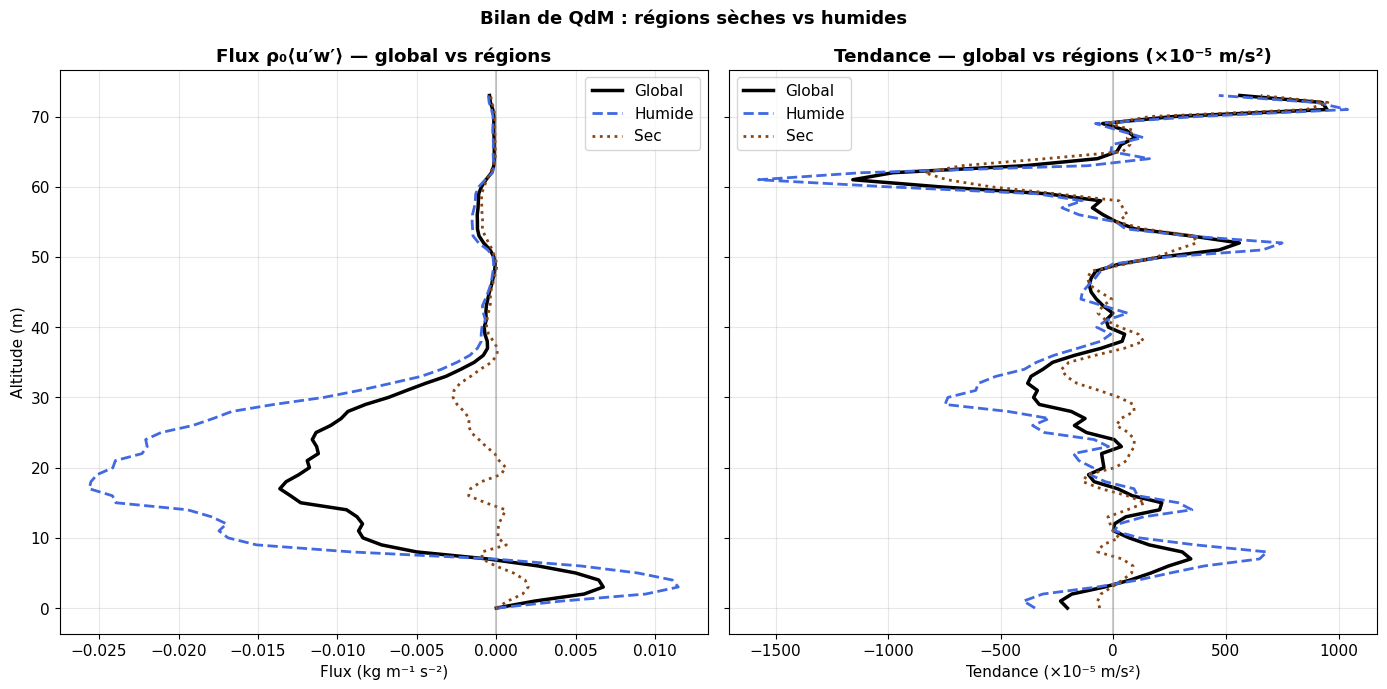

In [40]:
flux_h = np.zeros(n_z)
flux_s = np.zeros(n_z)

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

for iz in range(n_z):
    sl = {dim_t: idx_stat, dim_z: iz}

    u_lev = ds_u['ua'].isel(sl).values   # (n_stat, ny, nx)
    w_lev = ds_w['wa'].isel(sl).values

    u_p = u_lev - u_lev.mean(axis=(1, 2), keepdims=True)
    w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
    flux_loc = rho0[iz] * u_p * w_p   # (n_stat, ny, nx)

    # mh / ms sont des masques 2D (ny, nx) construits tout ne haut (représentation des colonnes)
    # on les broadcast sur l'axe temps
    flux_h[iz] = flux_loc[:, mh].mean()
    flux_s[iz] = flux_loc[:, ms].mean()

    del u_lev, w_lev, u_p, w_p, flux_loc
    gc.collect()

    if iz % 10 == 0:
        print(f'  Niveau {iz}/{n_z-1}')

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()

tend_h = tendance(flux_h)
tend_s = tendance(flux_s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

ax1.plot(flux_uw, alt, 'k-',  lw=2.5, label='Global')
ax1.plot(flux_h,  alt, color='royalblue',   lw=2, linestyle='--', label='Humide')
ax1.plot(flux_s,  alt, color='saddlebrown', lw=2, linestyle=':',  label='Sec')
ax1.axvline(0, color='grey', alpha=0.4)
ax1.set_title('Flux ρ₀⟨u′w′⟩ — global vs régions', fontweight='bold')
ax1.set_xlabel('Flux (kg m⁻¹ s⁻²)') ; ax1.set_ylabel('Altitude (m)')
ax1.legend() ; ax1.grid(True, alpha=0.3)

ax2.plot(tend_u_glob * 1e5, alt, 'k-',  lw=2.5, label='Global')
ax2.plot(tend_h * 1e5,      alt, color='royalblue',   lw=2, linestyle='--', label='Humide')
ax2.plot(tend_s * 1e5,      alt, color='saddlebrown', lw=2, linestyle=':',  label='Sec')
ax2.axvline(0, color='grey', alpha=0.4)
ax2.set_title('Tendance — global vs régions (×10⁻⁵ m/s²)', fontweight='bold')
ax2.set_xlabel('Tendance (×10⁻⁵ m/s²)')
ax2.legend() ; ax2.grid(True, alpha=0.3)

plt.suptitle('Bilan de QdM : régions sèches vs humides', fontsize=13, fontweight='bold')
plt.tight_layout() ; plt.show()


## 10. Évolution temporelle du flux de Reynolds intégré

On intègre ρ₀⟨u′w′⟩ verticalement (0–15 km) à chaque pas de temps.  
Ici on traite **un pas de temps à la fois** — un seul niveau de mémoire.


  t=0/99
  t=20/99
  t=40/99
  t=60/99
  t=80/99


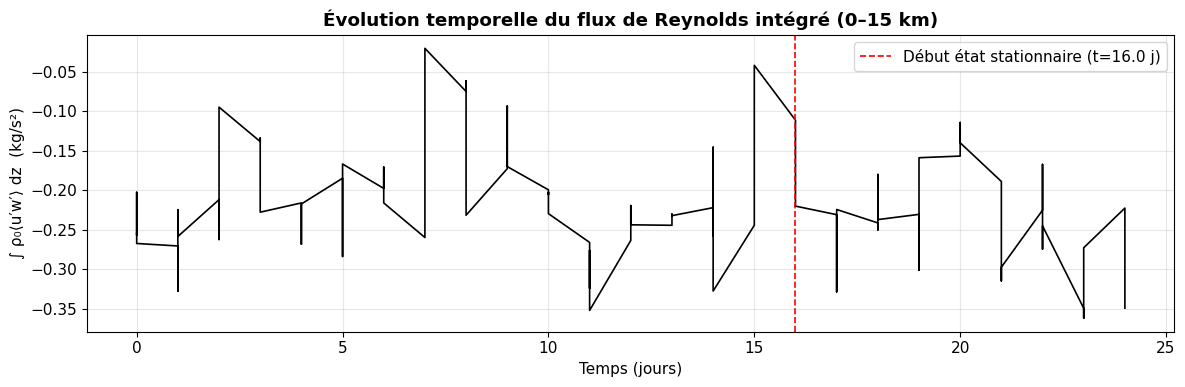

In [41]:
idx_tropo = np.searchsorted(alt, 15000)
alt_tropo = alt[:idx_tropo]
rho0_tropo = rho0[:idx_tropo]

flux_int_time = np.zeros(n_t)

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

for it in range(n_t):
    sl = {dim_t: it}

    u_t = ds_u['ua'].isel(sl).values   # (z, ny, nx)
    w_t = ds_w['wa'].isel(sl).values

    u_p = u_t - u_t.mean(axis=(1, 2), keepdims=True)
    w_p = w_t - w_t.mean(axis=(1, 2), keepdims=True)

    # Flux moyen horizontal à chaque niveau, intégré verticalement
    flux_prof = (rho0[:, None, None] * u_p * w_p).mean(axis=(1, 2))  # (z,)
    flux_int_time[it] = np.trapz(flux_prof[:idx_tropo], alt_tropo)

    del u_t, w_t, u_p, w_p, flux_prof
    if it % 20 == 0:
        gc.collect()
        print(f'  t={it}/{n_t-1}')

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_days, flux_int_time, color='black', lw=1.2)
ax.axvline(time_days[t_stat], color='red', lw=1.2, linestyle='--',
           label=f'Début état stationnaire (t={time_days[t_stat]:.1f} j)')
ax.set_xlabel('Temps (jours)') ; ax.set_ylabel('∫ ρ₀⟨u′w′⟩ dz  (kg/s²)')
ax.set_title('Évolution temporelle du flux de Reynolds intégré (0–15 km)', fontweight='bold')
ax.legend() ; ax.grid(True, alpha=0.3)
plt.tight_layout() ; plt.show()


---
# Synthèse et interprétation des résultats

## Ce que la simulation montre

### Auto-agrégation convective

La variance spatiale de la PRW au cours du temps est le premier indicateur à lire.  
Si elle **augmente** progressivement avant de se stabiliser, la simulation développe  
bien une auto-agrégation : les colonnes convectives se regroupent spontanément,  
laissant de grandes zones subsidentes sèches autour d'elles.  
La carte PRW moyenne confirme visuellement cette organisation : on doit observer  
des structures spatiales cohérentes (amas humides entourés de zones sèches),  
et non un champ homogène.

La **distribution de PRW bimodale** — un mode sec autour de 20–30 kg/m²  
et un mode humide autour de 60–70 kg/m² — est la signature thermodynamique  
de cette agrégation. Dans une simulation non agrégée (RCE homogène),  
la distribution serait unimodale et étroite.

---

### Profil de densité ρ₀ et vent moyen

Le profil ρ₀(z) décroît d'environ **1.2 kg/m³ en surface** à **~0.3 kg/m³ à 10 km**,  
soit un facteur 4. Cette décroissance est fondamentale pour le bilan de QdM :  
un même flux u′w′ en altitude pèse 4 fois moins lourd en termes de force  
qu'en surface. C'est pourquoi on travaille avec ρ₀ u′w′ et non u′w′ seul.

Le profil de vent moyen à l'état stationnaire reflète l'équilibre entre  
le forçage de surface (friction), les flux turbulents et le rappel de grande échelle.

---

### Bilan global de quantité de mouvement

Le flux de Reynolds global ρ₀⟨u′w′⟩(z) et sa divergence verticale donnent  
la **tendance nette exercée par la turbulence sur le vent moyen** à chaque altitude.

Physiquement, deux comportements sont attendus :

- **Dans la couche limite (0–2 km)** : le flux doit être négatif (u′w′ < 0)  
  car les updrafts transportent de l'air lent (freiné par la surface) vers le haut,  
  tandis que les downdrafts ramènent de l'air plus rapide vers le bas.  
  La divergence de ce flux correspond à une **décélération** du vent en surface  
  et une **accélération** dans la couche limite supérieure.

- **Dans la troposphère libre (2–15 km)** : le flux diminue avec l'altitude  
  car la convection perd de l'énergie. Sa divergence tends vers zéro au-dessus  
  de la tropopause.

Si le flux change de signe avec l'altitude, cela indique que la turbulence  
**accélère** le vent dans certaines couches et le **freine** dans d'autres —  
c'est le mécanisme central de communication de la friction de surface.

---

### Décomposition par régime turbulent

La décomposition en quatre régimes permet de répondre à la question centrale :  
**quel type de turbulence est responsable du transport vertical de QdM ?**

- **Convection nuageuse** : contribution attendue dominante dans la troposphère libre.  
  Les updrafts convectifs forts (w′ > 0.05 m/s avec condensats) transportent  
  efficacement la QdM sur de grandes hauteurs. Si ce terme domine,  
  c'est la convection profonde qui relie la surface à la haute troposphère.

- **Thermiques secs (CBL)** : contribution concentrée dans la couche limite  
  (0–2 km typiquement). C'est la turbulence sèche de couche limite qui assure  
  le premier étage du transport, de la surface jusqu'à la base des nuages.

- **Subsidence** : contribution de signe opposé à la convection.  
  Les downdrafts ramènent de la QdM d'altitude vers la surface.  
  Ce terme est souvent sous-estimé mais peut être significatif dans les zones sèches.

- **Petite turbulence (résidu)** : si ce terme est négligeable, la décomposition  
  en trois régimes est physiquement cohérente. S'il est grand, cela indique  
  que des processus non capturés par les seuils w′ et qc contribuent au transport.

---

### Bilan par région sec / humide

C'est le diagnostic le plus directement lié à l'auto-agrégation.

**Dans les colonnes humides** (convectives), on attend un flux de Reynolds  
fort et orienté vers le haut sur toute la troposphère — c'est là que se passe  
l'essentiel du transport vertical de QdM.

**Dans les colonnes sèches** (subsidentes), le flux doit être faible et de signe  
opposé — la subsidence lente ramène un peu de QdM vers le bas, mais le signal  
est dilué sur une grande surface.

Si le flux dans les colonnes humides est **beaucoup plus grand** que le flux global,  
cela confirme que l'agrégation **concentre** le transport de QdM dans une fraction  
réduite du domaine. En d'autres termes, l'auto-agrégation modifie profondément  
la façon dont la friction de surface est communiquée à la troposphère :
au lieu d'être distribuée uniformément, elle est concentrée dans les zones convectives.

---

### Évolution temporelle

Le flux intégré verticalement au cours du temps doit se stabiliser quand  
la simulation atteint l'état stationnaire — c'est une validation a posteriori  
du choix de `t_stat`. Une dérive résiduelle indiquerait que l'état stationnaire  
n'est pas encore atteint et qu'il faudrait décaler `t_stat` vers la fin.

---

## Suite — améliorations du bilan de QdM

Les sections suivantes approfondissent le bilan avec trois diagnostics supplémentaires :

1. **Profils conditionnels u(z) par région** — profil de vent moyen séparément  
   dans les colonnes sèches et humides, pour voir si le vent est structurellement  
   différent dans les deux régimes.

2. **Bilan conditionnel croisé** — décomposition par régime turbulent  
   *à l'intérieur* de chaque région (sec/humide), soit 8 contributions au total.

3. **Carte 2D du flux de surface** — carte (x, y) du flux ρ₀ u′w′ au premier  
   niveau du modèle, superposée au masque sec/humide, pour voir si le transport  
   de QdM est bien localisé dans les zones convectives.


## 12. Profils de vent conditionnels (sec / humide)

On calcule le profil de vent moyen ⟨u⟩(z) séparément dans les colonnes  
sèches et humides. Si l'agrégation est présente, les deux profils doivent  
diverger : les colonnes convectives ont un cisaillement de vent différent  
des colonnes subsidentes.


In [ ]:
# ======================================================================
# Profils de vent moyen conditionnels — sec vs humide
# Même stratégie : un niveau à la fois, masques appliqués sur (y, x)
# ======================================================================

u_moy_h = np.zeros(n_z)   # vent moyen dans les colonnes humides
u_moy_s = np.zeros(n_z)   # vent moyen dans les colonnes sèches
u_moy_g = np.zeros(n_z)   # vent moyen global

ds_u = xr.open_dataset(path3d('ua'))

for iz in range(n_z):
    sl = {dim_t: idx_stat, dim_z: iz}
    u_lev = ds_u['ua'].isel(sl).values   # (n_stat, ny, nx)

    # Moyenne temporelle puis spatiale conditionnelle
    u_t = u_lev.mean(axis=0)             # (ny, nx) — moyenne temporelle
    u_moy_h[iz] = u_t[mh].mean()
    u_moy_s[iz] = u_t[ms].mean()
    u_moy_g[iz] = u_t.mean()

    del u_lev, u_t

ds_u.close()
del ds_u
gc.collect()

# --- Visualisation ---
fig, ax = plt.subplots(figsize=(6, 8))
ax.plot(u_moy_g, alt, 'k-',  lw=2.5, label='Global')
ax.plot(u_moy_h, alt, color='royalblue',   lw=2, linestyle='--', label='Humide')
ax.plot(u_moy_s, alt, color='saddlebrown', lw=2, linestyle=':',  label='Sec')
ax.axvline(0, color='grey', alpha=0.4)
ax.set_xlabel('Vent zonal moyen u (m/s)')
ax.set_ylabel('Altitude (m)')
ax.set_title('Profils de vent conditionnel\nsec / humide — état stationnaire',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Différence humide - sec : cisaillement différentiel
fig, ax = plt.subplots(figsize=(6, 8))
ax.plot(u_moy_h - u_moy_s, alt, color='purple', lw=2)
ax.axvline(0, color='grey', alpha=0.5)
ax.fill_betweenx(alt, u_moy_h - u_moy_s, 0,
                 where=(u_moy_h - u_moy_s > 0), alpha=0.15, color='royalblue',
                 label='Humide plus rapide')
ax.fill_betweenx(alt, u_moy_h - u_moy_s, 0,
                 where=(u_moy_h - u_moy_s < 0), alpha=0.15, color='saddlebrown',
                 label='Sec plus rapide')
ax.set_xlabel('u_humide - u_sec (m/s)')
ax.set_ylabel('Altitude (m)')
ax.set_title('Différence de vent zonal\nhumide minus sec', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Bilan conditionnel croisé — régimes turbulents × régions

On décompose le flux ρ₀⟨u′w′⟩ simultanément selon le régime turbulent  
(convection, thermiques secs, subsidence) **et** selon la région (sec/humide).  
Cela donne 6 contributions qui permettent de répondre à :  
*dans quelle région et par quel mécanisme la QdM est-elle principalement transportée ?*


In [ ]:
# ======================================================================
# Bilan conditionnel croisé : régime turbulent × région sec/humide
# 6 flux : conv_h, conv_s, sec_h, sec_s, sub_h, sub_s
# ======================================================================

flux_conv_h = np.zeros(n_z)
flux_conv_s = np.zeros(n_z)
flux_sec_h  = np.zeros(n_z)
flux_sec_s  = np.zeros(n_z)
flux_sub_h  = np.zeros(n_z)
flux_sub_s  = np.zeros(n_z)

ds_u   = xr.open_dataset(path3d('ua'))
ds_w   = xr.open_dataset(path3d('wa'))
ds_clw = xr.open_dataset(path3d('clw'))
ds_cli = xr.open_dataset(path3d('cli'))

for iz in range(n_z):
    sl = {dim_t: idx_stat, dim_z: iz}

    u_lev   = ds_u['ua'].isel(sl).values
    w_lev   = ds_w['wa'].isel(sl).values
    clw_lev = ds_clw['clw'].isel(sl).values
    cli_lev = ds_cli['cli'].isel(sl).values

    u_p = u_lev - u_lev.mean(axis=(1, 2), keepdims=True)
    w_p = w_lev - w_lev.mean(axis=(1, 2), keepdims=True)
    qc  = clw_lev + cli_lev

    flux_loc = rho0[iz] * u_p * w_p   # (n_stat, ny, nx)

    # Masques turbulents
    m_conv = (w_p >  SEUIL_W) & (qc >  SEUIL_QC)
    m_sec  = (w_p >  SEUIL_W) & (qc <= SEUIL_QC)
    m_sub  = (w_p < -SEUIL_W)

    # Masques régionaux broadcast sur l'axe temps
    # mh/ms : (ny, nx) → on sélectionne sur les axes 1,2 du tableau (n_stat, ny, nx)
    def flux_cond_region(masque_turb, masque_region):
        """Flux moyen dans les points vérifiant les deux masques."""
        m = masque_turb & masque_region[np.newaxis, :, :]
        return np.where(m, flux_loc, 0.0).mean()

    flux_conv_h[iz] = flux_cond_region(m_conv, mh)
    flux_conv_s[iz] = flux_cond_region(m_conv, ms)
    flux_sec_h[iz]  = flux_cond_region(m_sec,  mh)
    flux_sec_s[iz]  = flux_cond_region(m_sec,  ms)
    flux_sub_h[iz]  = flux_cond_region(m_sub,  mh)
    flux_sub_s[iz]  = flux_cond_region(m_sub,  ms)

    del u_lev, w_lev, clw_lev, cli_lev, u_p, w_p, qc, flux_loc
    del m_conv, m_sec, m_sub
    gc.collect()

    if iz % 10 == 0:
        print(f'  Niveau {iz}/{n_z-1}  ({alt[iz]:.0f} m)')

ds_u.close() ; ds_w.close() ; ds_clw.close() ; ds_cli.close()
del ds_u, ds_w, ds_clw, ds_cli
gc.collect()

print('Bilan croisé calculé.')


In [ ]:
# --- Visualisation : 2 panneaux (humide / sec), 3 courbes chacun ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

kw_conv = dict(color='crimson',    lw=2, linestyle='--')
kw_sec  = dict(color='darkorange', lw=2, linestyle='--')
kw_sub  = dict(color='royalblue',  lw=2, linestyle=':')
kw_tot  = dict(color='black',      lw=2.5)

ax1.plot(flux_h,      alt, label='Total humide', **kw_tot)
ax1.plot(flux_conv_h, alt, label='Convection nuageuse', **kw_conv)
ax1.plot(flux_sec_h,  alt, label='Thermiques secs',     **kw_sec)
ax1.plot(flux_sub_h,  alt, label='Subsidence',           **kw_sub)
ax1.axvline(0, color='grey', alpha=0.4)
ax1.set_title('Région HUMIDE\nFlux rho0 u-prime w-prime par regime',
              fontweight='bold')
ax1.set_xlabel('Flux (kg m-1 s-2)')
ax1.set_ylabel('Altitude (m)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(flux_s,      alt, label='Total sec',   **kw_tot)
ax2.plot(flux_conv_s, alt, label='Convection nuageuse', **kw_conv)
ax2.plot(flux_sec_s,  alt, label='Thermiques secs',     **kw_sec)
ax2.plot(flux_sub_s,  alt, label='Subsidence',           **kw_sub)
ax2.axvline(0, color='grey', alpha=0.4)
ax2.set_title('Région SECHE\nFlux rho0 u-prime w-prime par regime',
              fontweight='bold')
ax2.set_xlabel('Flux (kg m-1 s-2)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Bilan croise : regime turbulent x region sec/humide',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 14. Carte 2D du flux de Reynolds au premier niveau

On visualise la carte (x, y) de ρ₀ u′w′ au niveau le plus bas du modèle  
(premier niveau au-dessus de la surface), superposée au contour du masque humide.  
Cela montre directement si le transport de QdM est localisé dans les zones convectives.


In [ ]:
# ======================================================================
# Carte 2D du flux de Reynolds au niveau de surface (iz=0)
# Moyenne temporelle sur l'état stationnaire
# ======================================================================

iz_surf = 0   # premier niveau du modèle

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

sl = {dim_t: idx_stat, dim_z: iz_surf}
u_surf = ds_u['ua'].isel(sl).values   # (n_stat, ny, nx)
w_surf = ds_w['wa'].isel(sl).values

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()

u_p_surf = u_surf - u_surf.mean(axis=(1, 2), keepdims=True)
w_p_surf = w_surf - w_surf.mean(axis=(1, 2), keepdims=True)

# Flux moyen temporel : (ny, nx)
flux_surf_2d = (rho0[iz_surf] * u_p_surf * w_p_surf).mean(axis=0)

del u_surf, w_surf, u_p_surf, w_p_surf
gc.collect()

# --- Carte avec contour du masque humide ---
fig, ax = plt.subplots(figsize=(8, 6))

# Amplitude max pour centrer la colorbar sur 0
vmax = np.abs(flux_surf_2d).max()
im = ax.pcolormesh(flux_surf_2d, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
fig.colorbar(im, ax=ax, label='rho0 u-prime w-prime  (kg m-1 s-2)')

# Contour du masque humide en noir
ax.contour(mh.astype(float), levels=[0.5], colors='black', linewidths=1.2,
           linestyles='--')

ax.set_title(f'Flux de Reynolds rho0 u-prime w-prime au niveau z={alt[iz_surf]:.0f} m\n'
             f'Contour noir = limite humide/sec (PRW > {PRW_SEUIL:.1f} kg/m2)',
             fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

# --- Même carte à mi-troposphère (~5 km) ---
iz_5km = np.argmin(np.abs(alt - 5000))
print(f'Niveau a ~5 km : iz={iz_5km}, alt={alt[iz_5km]:.0f} m')

ds_u = xr.open_dataset(path3d('ua'))
ds_w = xr.open_dataset(path3d('wa'))

sl = {dim_t: idx_stat, dim_z: iz_5km}
u_5km = ds_u['ua'].isel(sl).values
w_5km = ds_w['wa'].isel(sl).values

ds_u.close() ; ds_w.close()
del ds_u, ds_w
gc.collect()

u_p_5km = u_5km - u_5km.mean(axis=(1, 2), keepdims=True)
w_p_5km = w_5km - w_5km.mean(axis=(1, 2), keepdims=True)
flux_5km_2d = (rho0[iz_5km] * u_p_5km * w_p_5km).mean(axis=0)

del u_5km, w_5km, u_p_5km, w_p_5km
gc.collect()

fig, ax = plt.subplots(figsize=(8, 6))
vmax5 = np.abs(flux_5km_2d).max()
im = ax.pcolormesh(flux_5km_2d, cmap='RdBu_r', vmin=-vmax5, vmax=vmax5)
fig.colorbar(im, ax=ax, label='rho0 u-prime w-prime  (kg m-1 s-2)')
ax.contour(mh.astype(float), levels=[0.5], colors='black', linewidths=1.2,
           linestyles='--')
ax.set_title(f'Flux de Reynolds rho0 u-prime w-prime a ~5 km (z={alt[iz_5km]:.0f} m)\n'
             f'Contour noir = limite humide/sec',
             fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()


## 11. Notes méthodologiques

### Densité ρ₀
$$\rho_0(z) = \frac{\overline{p}}{R_d\,\overline{T_v}}, \quad T_v = T\,\frac{1+q_v/\varepsilon}{1+q_v}, \quad \varepsilon = R_d/R_v \approx 0.622$$

### Tenseur de Reynolds pondéré
On utilise ρ₀⟨u′w′⟩ [kg m⁻¹ s⁻²] pour que la divergence verticale donne  
directement une tendance en m/s² :  
$$\left(\frac{\partial u}{\partial t}\right)_\text{Reynolds} = -\frac{1}{\rho_0}\frac{\partial(\rho_0\overline{u'w'})}{\partial z}$$
